<a href="https://colab.research.google.com/github/amrrmadhn/sif504-w08-uts-crm/blob/master/SIF504_W08_UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [122]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Import Dataset

In [123]:
df = pd.read_csv('/content/online_retail_customer_churn.csv')
df

,Customer_ID,Age,Gender,Annual_Income,Total_Spend,Years_as_Customer,Num_of_Purchases,Average_Transaction_Amount,Num_of_Returns,Num_of_Support_Contacts,Satisfaction_Score,Last_Purchase_Days_Ago,Email_Opt_In,Promotion_Response,Target_Churn
0,1,62,Other,45.15,5892.58,5,22,453.80,2,0,3,129,True,Responded,True
1,2,65,Male,79.51,9025.47,13,77,22.90,2,2,3,227,False,Responded,False
2,3,18,Male,29.19,618.83,13,71,50.53,5,2,2,283,False,Responded,True
3,4,21,Other,79.63,9110.30,3,33,411.83,5,3,5,226,True,Ignored,True
4,5,21,Other,77.66,5390.88,15,43,101.19,3,0,5,242,False,Unsubscribed,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,54,Male,143.72,1089.09,2,29,77.75,0,3,2,88,True,Ignored,False
996,997,19,Male,164.19,3700.24,9,90,34.45,6,4,4,352,False,Responded,True
997,998,47,Female,113.31,705.85,17,69,187.37,7,3,1,172,True,Unsubscribed,False
998,999,23,Male,72.98,3891.60,7,31,483.80,1,2,5,55,False,Responded,True


# EDA

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 1000 non-null   int64  
 1   Age                         1000 non-null   int64  
 2   Gender                      1000 non-null   object 
 3   Annual_Income               1000 non-null   float64
 4   Total_Spend                 1000 non-null   float64
 5   Years_as_Customer           1000 non-null   int64  
 6   Num_of_Purchases            1000 non-null   int64  
 7   Average_Transaction_Amount  1000 non-null   float64
 8   Num_of_Returns              1000 non-null   int64  
 9   Num_of_Support_Contacts     1000 non-null   int64  
 10  Satisfaction_Score          1000 non-null   int64  
 11  Last_Purchase_Days_Ago      1000 non-null   int64  
 12  Email_Opt_In                1000 non-null   bool   
 13  Promotion_Response          1000 n

In [125]:
# cek jumlah data & atribut
print(df.shape)

(1000, 15)


In [126]:
# cek missing value
print(df.isnull().sum())

Customer_ID                   0
Age                           0
Gender                        0
Annual_Income                 0
Total_Spend                   0
Years_as_Customer             0
Num_of_Purchases              0
Average_Transaction_Amount    0
Num_of_Returns                0
Num_of_Support_Contacts       0
Satisfaction_Score            0
Last_Purchase_Days_Ago        0
Email_Opt_In                  0
Promotion_Response            0
Target_Churn                  0
dtype: int64


In [127]:
# cek distribusi target
print(df['Target_Churn'].value_counts())

Target_Churn
True     526
False    474
Name: count, dtype: int64


# Pre-processing Data

## Drop Customer ID

In [128]:
df = df.drop(columns=['Customer_ID'])
df.head()

,Age,Gender,Annual_Income,Total_Spend,Years_as_Customer,Num_of_Purchases,Average_Transaction_Amount,Num_of_Returns,Num_of_Support_Contacts,Satisfaction_Score,Last_Purchase_Days_Ago,Email_Opt_In,Promotion_Response,Target_Churn
0,62,Other,45.15,5892.58,5,22,453.80,2,0,3,129,True,Responded,True
1,65,Male,79.51,9025.47,13,77,22.90,2,2,3,227,False,Responded,False
2,18,Male,29.19,618.83,13,71,50.53,5,2,2,283,False,Responded,True
3,21,Other,79.63,9110.30,3,33,411.83,5,3,5,226,True,Ignored,True
4,21,Other,77.66,5390.88,15,43,101.19,3,0,5,242,False,Unsubscribed,False


## Encoding

In [129]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [130]:
df

,Age,Gender,Annual_Income,Total_Spend,Years_as_Customer,Num_of_Purchases,Average_Transaction_Amount,Num_of_Returns,Num_of_Support_Contacts,Satisfaction_Score,Last_Purchase_Days_Ago,Email_Opt_In,Promotion_Response,Target_Churn
0,62,2,45.15,5892.58,5,22,453.80,2,0,3,129,True,1,True
1,65,1,79.51,9025.47,13,77,22.90,2,2,3,227,False,1,False
2,18,1,29.19,618.83,13,71,50.53,5,2,2,283,False,1,True
3,21,2,79.63,9110.30,3,33,411.83,5,3,5,226,True,0,True
4,21,2,77.66,5390.88,15,43,101.19,3,0,5,242,False,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,54,1,143.72,1089.09,2,29,77.75,0,3,2,88,True,0,False
996,19,1,164.19,3700.24,9,90,34.45,6,4,4,352,False,1,True
997,47,0,113.31,705.85,17,69,187.37,7,3,1,172,True,2,False
998,23,1,72.98,3891.60,7,31,483.80,1,2,5,55,False,1,True


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         1000 non-null   int64  
 1   Gender                      1000 non-null   int64  
 2   Annual_Income               1000 non-null   float64
 3   Total_Spend                 1000 non-null   float64
 4   Years_as_Customer           1000 non-null   int64  
 5   Num_of_Purchases            1000 non-null   int64  
 6   Average_Transaction_Amount  1000 non-null   float64
 7   Num_of_Returns              1000 non-null   int64  
 8   Num_of_Support_Contacts     1000 non-null   int64  
 9   Satisfaction_Score          1000 non-null   int64  
 10  Last_Purchase_Days_Ago      1000 non-null   int64  
 11  Email_Opt_In                1000 non-null   bool   
 12  Promotion_Response          1000 non-null   int64  
 13  Target_Churn                1000 n

In [132]:
print(df['Gender'].unique())

[2 1 0]


## Correlation

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

In [134]:
corr = df.corr()

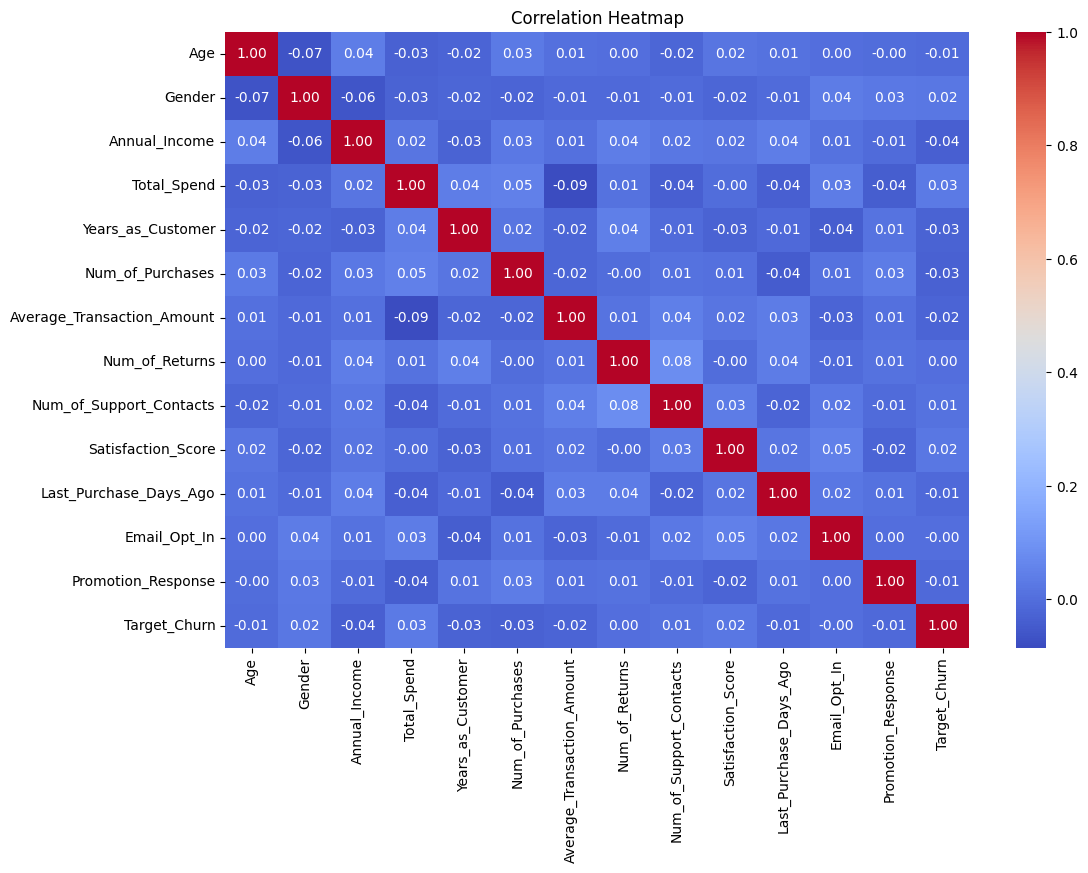

In [135]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,        # tampilkan angka
    fmt=".2f",         # 2 desimal
    cmap="coolwarm"    # warna
)

plt.title("Correlation Heatmap")
plt.show()

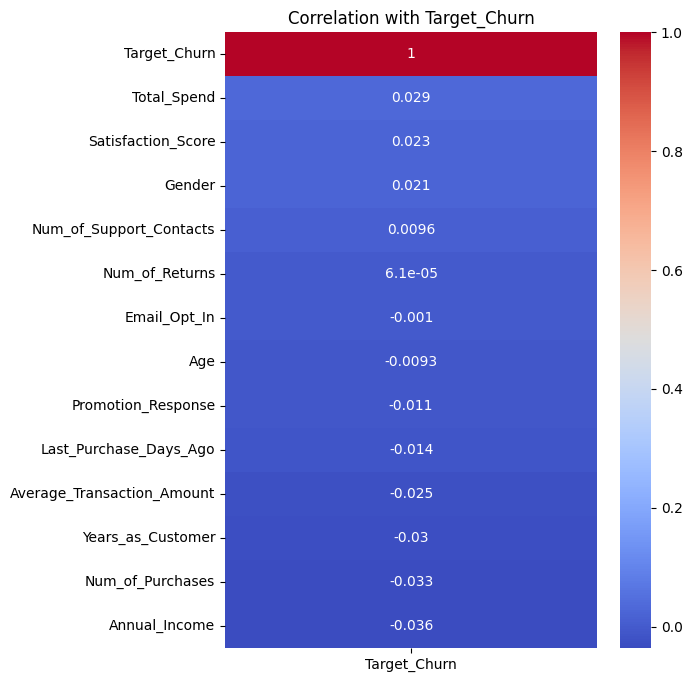

In [136]:
plt.figure(figsize=(6,8))

corr_target = df.corr()[['Target_Churn']].sort_values(by='Target_Churn', ascending=False)

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation with Target_Churn")
plt.show()

## Target & Feature

In [137]:
X = df.drop('Target_Churn', axis=1)
y = df['Target_Churn']

In [138]:
print(y)

0       True
1      False
2       True
3       True
4      False
       ...  
995    False
996     True
997    False
998     True
999     True
Name: Target_Churn, Length: 1000, dtype: bool


In [139]:
top_features = [
    'Last_Purchase_Days_Ago',     # jarang beli → churn
    'Num_of_Purchases',           # frekuensi
    'Years_as_Customer',          # loyalitas
]

X = df[top_features]
y = df['Target_Churn']

In [140]:
print(X)

     Last_Purchase_Days_Ago  Num_of_Purchases  Years_as_Customer
0                       129                22                  5
1                       227                77                 13
2                       283                71                 13
3                       226                33                  3
4                       242                43                 15
..                      ...               ...                ...
995                      88                29                  2
996                     352                90                  9
997                     172                69                 17
998                      55                31                  7
999                     269                48                 15

[1000 rows x 3 columns]


## Split data

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Decision Tree Model

In [107]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=6, min_samples_leaf=5, random_state=42)

In [142]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,   # lebih simpel
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, min_samples_leaf=5, random_state=42)

In [143]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

                  feature  importance
0  Last_Purchase_Days_Ago    0.488748
2       Years_as_Customer    0.299446
1        Num_of_Purchases    0.211806


## Model Evaluation

In [144]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.48

Confusion Matrix:
 [[ 9 86]
 [18 87]]

Classification Report:
               precision    recall  f1-score   support

       False       0.33      0.09      0.15        95
        True       0.50      0.83      0.63       105

    accuracy                           0.48       200
   macro avg       0.42      0.46      0.39       200
weighted avg       0.42      0.48      0.40       200



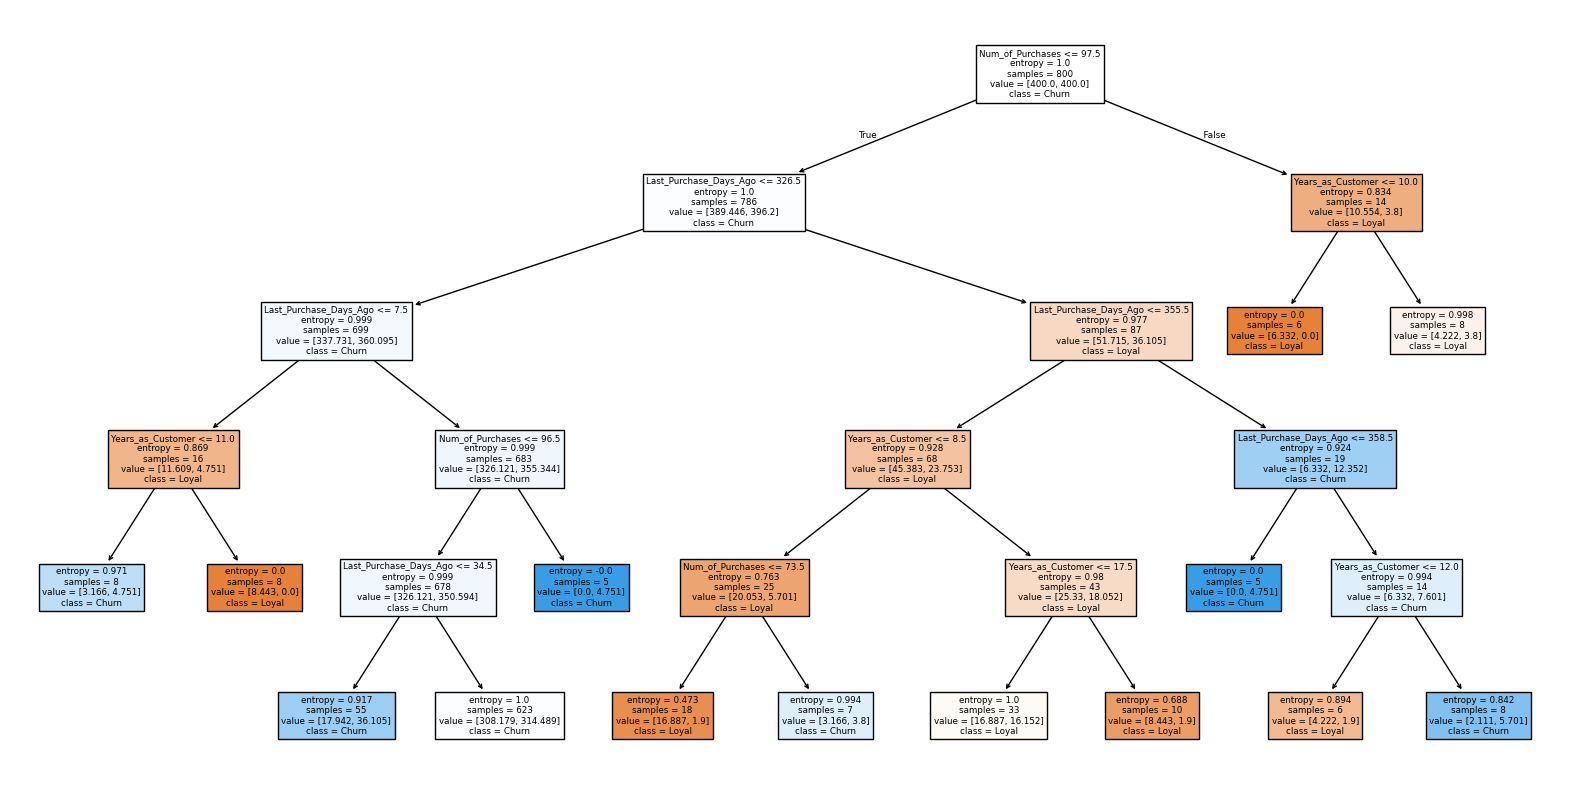

In [147]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Loyal', 'Churn'],
    filled=True
)

plt.show()

In [146]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.48

# Rule

In [148]:
from sklearn.tree import export_text

rules = export_text(model, feature_names=list(X.columns))
print(rules)

|--- Num_of_Purchases <= 97.50
|   |--- Last_Purchase_Days_Ago <= 326.50
|   |   |--- Last_Purchase_Days_Ago <= 7.50
|   |   |   |--- Years_as_Customer <= 11.00
|   |   |   |   |--- class: True
|   |   |   |--- Years_as_Customer >  11.00
|   |   |   |   |--- class: False
|   |   |--- Last_Purchase_Days_Ago >  7.50
|   |   |   |--- Num_of_Purchases <= 96.50
|   |   |   |   |--- Last_Purchase_Days_Ago <= 34.50
|   |   |   |   |   |--- class: True
|   |   |   |   |--- Last_Purchase_Days_Ago >  34.50
|   |   |   |   |   |--- class: True
|   |   |   |--- Num_of_Purchases >  96.50
|   |   |   |   |--- class: True
|   |--- Last_Purchase_Days_Ago >  326.50
|   |   |--- Last_Purchase_Days_Ago <= 355.50
|   |   |   |--- Years_as_Customer <= 8.50
|   |   |   |   |--- Num_of_Purchases <= 73.50
|   |   |   |   |   |--- class: False
|   |   |   |   |--- Num_of_Purchases >  73.50
|   |   |   |   |   |--- class: True
|   |   |   |--- Years_as_Customer >  8.50
|   |   |   |   |--- Years_as_Customer <= 